In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm

In [6]:
import seaborn as sns

In [ ]:
!pip install implicit

In [3]:
!ls -lh KION_DATASET-main.zip

-rw-r--r-- 1 root root 194M Mar 11 20:11 KION_DATASET-main.zip


In [4]:
!unzip KION_DATASET-main.zip

Archive:  KION_DATASET-main.zip
f69775be31fa5779907cf0a92ddedb70037fb5ae
   creating: KION_DATASET-main/
  inflating: KION_DATASET-main/README.md  
 extracting: KION_DATASET-main/data_en.zip  
   creating: KION_DATASET-main/data_en/
  inflating: KION_DATASET-main/data_en/items_en.csv  
  inflating: KION_DATASET-main/data_en/users_en.csv  
 extracting: KION_DATASET-main/data_original.zip  
   creating: KION_DATASET-main/data_original/
  inflating: KION_DATASET-main/data_original/items.csv  
  inflating: KION_DATASET-main/data_original/users.csv  
 extracting: KION_DATASET-main/interactions.csv.zip  
  inflating: KION_DATASET-main/sample_submission.csv  


In [ ]:
!unzip KION_DATASET-main

Archive:  KION_DATASET-main.zip
f69775be31fa5779907cf0a92ddedb70037fb5ae
replace KION_DATASET-main/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# EDA

In [7]:
users = pd.read_csv('/content/KION_DATASET-main/data_original/users.csv')
items = pd.read_csv('/content/KION_DATASET-main/data_original/items.csv')
interactions = pd.read_csv('/content/KION_DATASET-main/interactions.csv.zip')


**Действия пользователей**

In [ ]:
interactions.head(3)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0


In [ ]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594787 entries, 0 to 1594786
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   user_id        1594787 non-null  int64  
 1   item_id        1594787 non-null  int64  
 2   last_watch_dt  1594787 non-null  object 
 3   total_dur      1594786 non-null  float64
 4   watched_pct    1594519 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 60.8+ MB


In [ ]:
interactions.isnull().sum()

,0
user_id,0
item_id,0
last_watch_dt,0
total_dur,1
watched_pct,268


<Axes: xlabel='total_dur'>

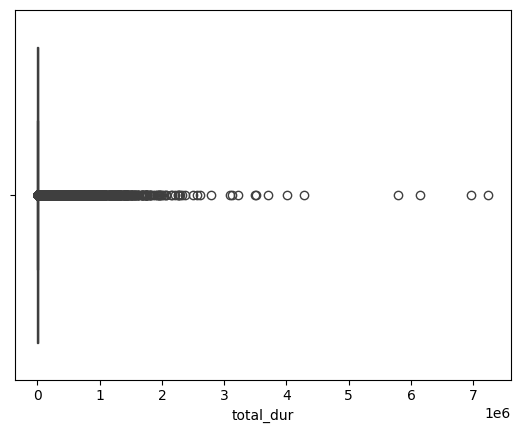

In [6]:
sns.boxplot(x=interactions['total_dur'])

Имеются выбросы, хорошо бы удалить

Отсекаем выбросы, значения которых выше 1.5 межквартильных размахов (IQR)

<Axes: xlabel='total_dur'>

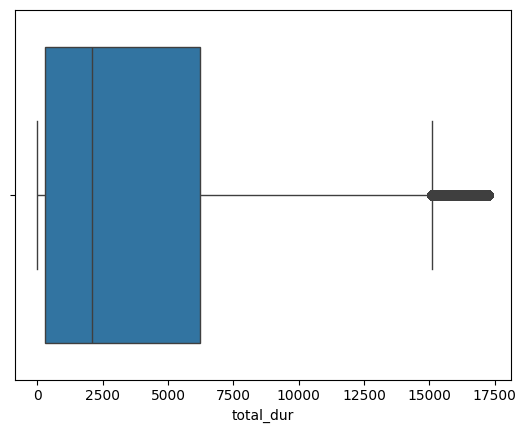

In [8]:
Q1 = interactions['total_dur'].quantile(0.25)
Q3 = interactions['total_dur'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

interactions = interactions[(interactions['total_dur'] >= lower_bound) &
                           (interactions['total_dur'] <= upper_bound)]


sns.boxplot(x=interactions['total_dur'])

<Axes: xlabel='total_dur', ylabel='Count'>

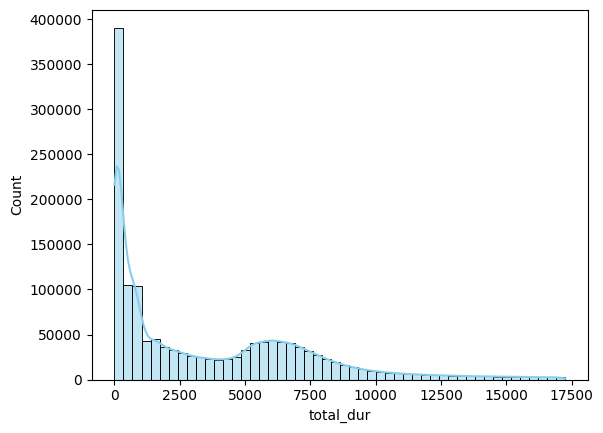

In [ ]:
sns.histplot(interactions['total_dur'], kde=True, bins=50, color='skyblue')

**Анализ пользователей**

In [ ]:
users.head(3)

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [ ]:
users.isnull().sum()

,0
user_id,0
age,14095
income,14776
sex,13831
kids_flg,0


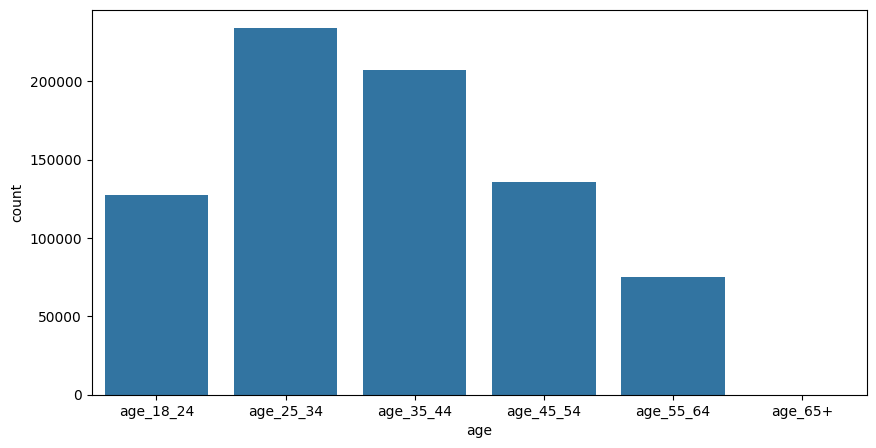

In [ ]:
age_order = ['age_18_24', 'age_25_34', 'age_35_44', 'age_45_54', 'age_55_64', 'age_65+']

plt.figure(figsize=(10, 5))
sns.countplot(data=users, x='age',order = age_order)
plt.show()

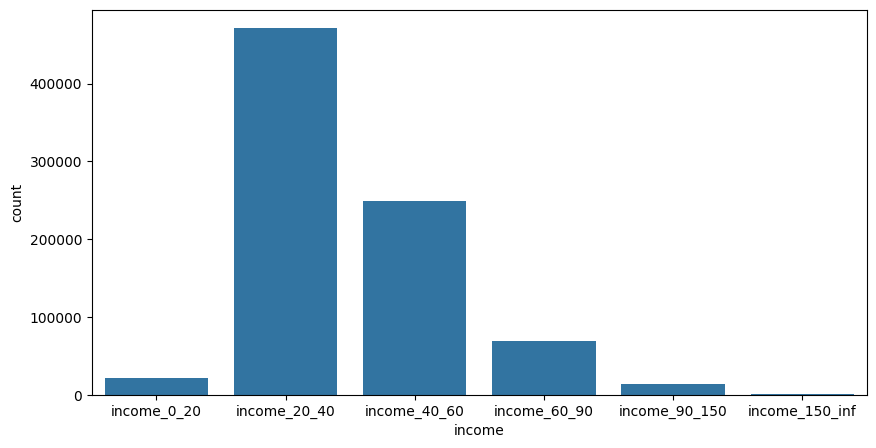

In [ ]:
income_order = ['income_0_20', 'income_20_40','income_40_60', 'income_60_90', 'income_90_150', 'income_150_inf']

plt.figure(figsize=(10, 5))
sns.countplot(data=users, x='income',order = income_order)
plt.show()

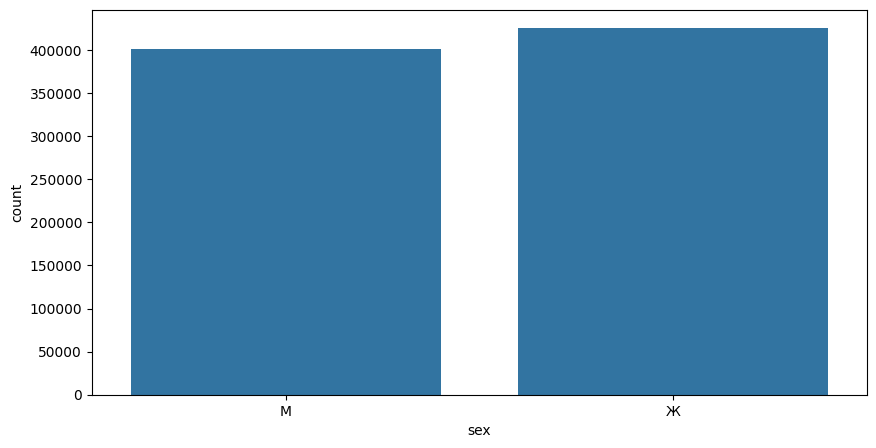

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=users, x='sex')
plt.show()

**Анализ фильмов**

In [ ]:
items.head(3)

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."


In [ ]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [ ]:
items.isnull().sum()


,0
item_id,0
content_type,0
title,0
title_orig,4745
release_year,98
genres,0
countries,37
for_kids,15397
age_rating,2
studios,14898


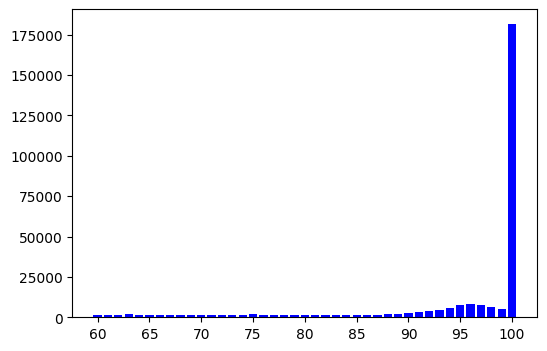

In [36]:
watch = interactions['watched_pct'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(watch.index, watch, color='blue')
plt.show()

Корреляция типа контента и пола

In [ ]:
from scipy.stats import chi2_contingency
ct = pd.crosstab(users['sex'], items['content_type'])


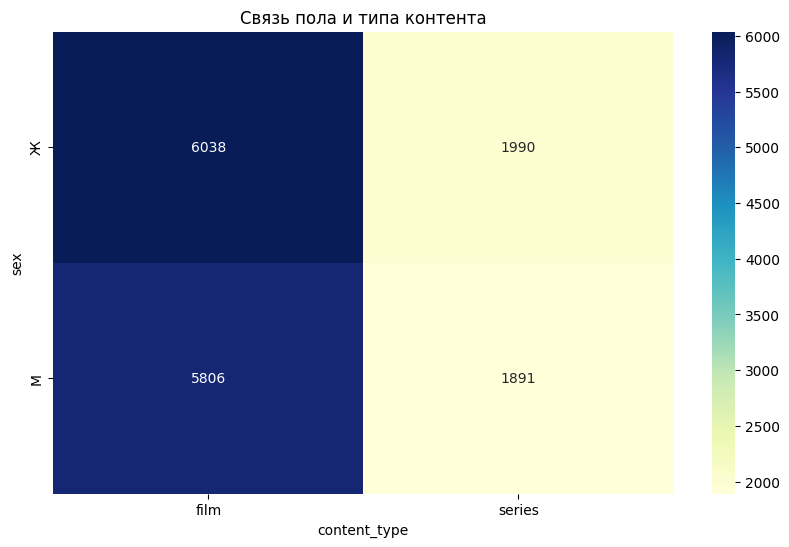

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Связь пола и типа контента')
plt.show()

In [ ]:
chi2, p, dof, ex = chi2_contingency(ct)

print(f"P-value: {p:.5f}")
if p < 0.05:
    print("Зависимость статистически значима")
else:
    print("Зависимость не обнаружена")

P-value: 0.76289
Зависимость не обнаружена


Люди больше смотрят фильмы чаще, нежели сериалы, вне зависимости от пола.

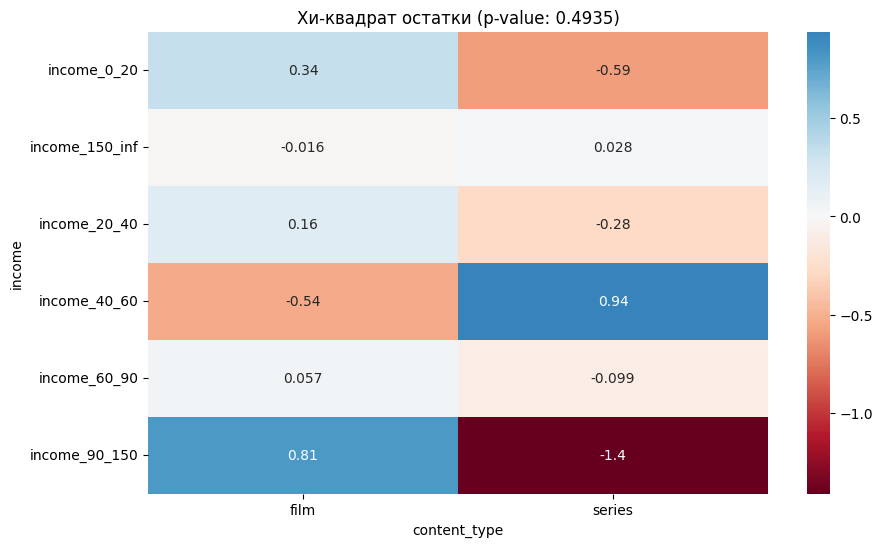

In [ ]:
ct = pd.crosstab(users['income'], items['content_type']) # сгруппируйте доход, если он числовой

# 2. Считаем Хи-квадрат
chi2, p, dof, expected = chi2_contingency(ct)

# 3. Считаем стандартизированные остатки Пирсона
# Формула: (Observed - Expected) / sqrt(Expected)
residuals = (ct - expected) / (expected ** 0.5)

# 4. Строим Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(residuals, annot=True, cmap='RdBu', center=0)

plt.title(f'Хи-квадрат остатки (p-value: {p:.4f})')
plt.show()

Построим график потребления контета разными возрастными группами (контент разных годов выпуска)

In [ ]:
z = list(items['release_year'])
print(sorted(z))
print(min(z),max(z))


[1933.0, 1941.0, 1954.0, 1955.0, 1956.0, 1960.0, 1962.0, 1964.0, 1966.0, 1967.0, 1968.0, 1969.0, 1974.0, 1975.0, 1975.0, 1975.0, 1976.0, 1976.0, 1976.0, 1978.0, 1979.0, 1979.0, 1981.0, 1981.0, 1981.0, 1981.0, 1982.0, 1982.0, 1983.0, 1984.0, 1984.0, 1985.0, 1985.0, 1986.0, 1986.0, 1986.0, 1986.0, 1987.0, 1989.0, 1989.0, 1990.0, 1991.0, 1992.0, 1992.0, 1993.0, 1993.0, 1994.0, 1994.0, 1994.0, 1994.0, 1994.0, 1996.0, 1997.0, 1997.0, 1997.0, 1998.0, 1999.0, 1999.0, 1999.0, 2000.0, 2000.0, 2001.0, 2001.0, 2001.0, 2001.0, 2001.0, 2002.0, 2002.0, 2002.0, 2003.0, 2003.0, 2003.0, 2003.0, 2004.0, 2004.0, 2004.0, 2004.0, 2004.0, 2004.0, 2004.0, 2004.0, 2004.0, 2005.0, 2005.0, 2005.0, 2006.0, 2006.0, 2006.0, 2007.0, 2007.0, 2007.0, 2007.0, 2007.0, 2007.0, 2007.0, 2007.0, 2008.0, 2008.0, 2008.0, 2008.0, 2008.0, 2008.0, 2009.0, 2009.0, 2009.0, 2009.0, 2009.0, 2009.0, 2009.0, 2009.0, 2009.0, 2010.0, 2010.0, 2010.0, 2010.0, 2010.0, 2010.0, 2010.0, 2011.0, 2011.0, 2011.0, 2011.0, 2011.0, 2011.0, 2011.0,

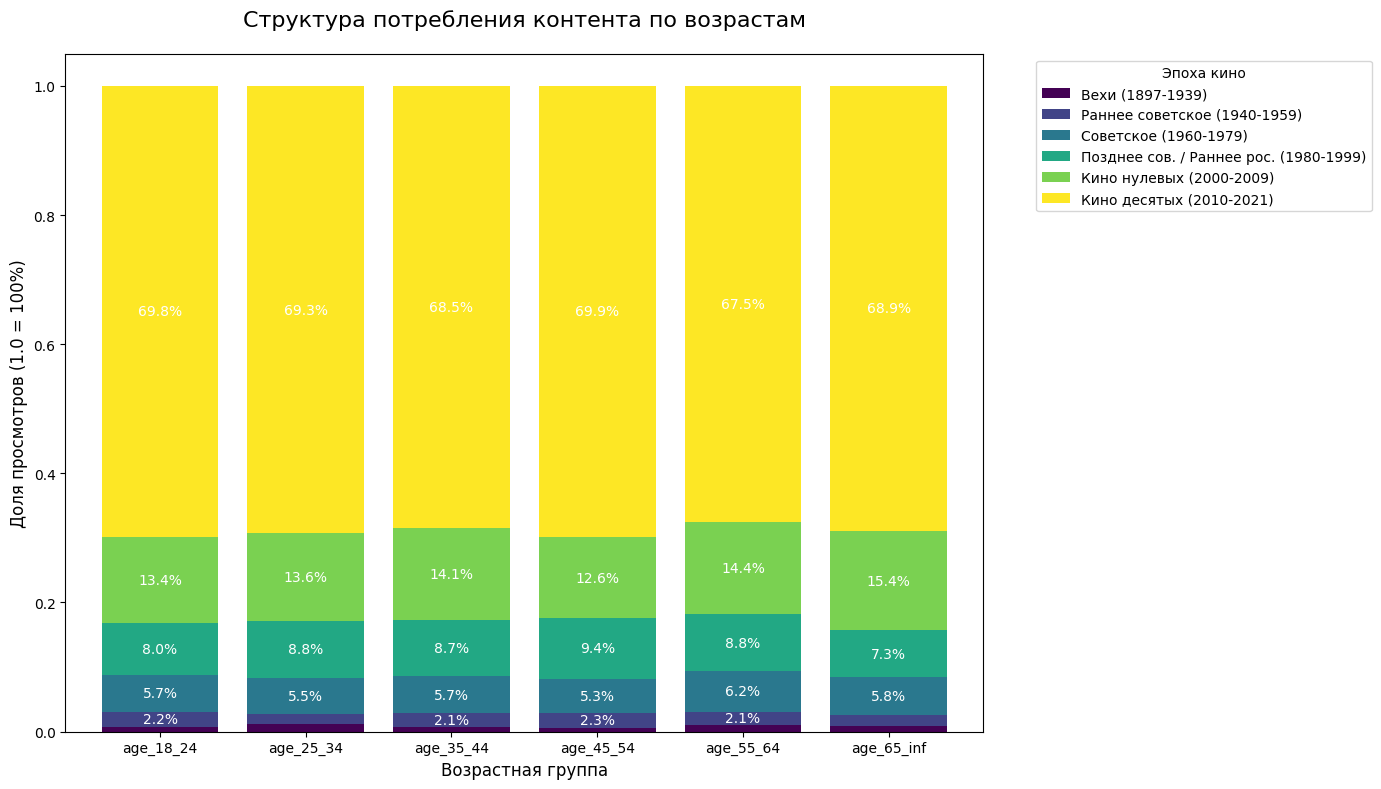

In [ ]:
bins = [1897, 1940, 1960, 1980, 2000, 2010, 2022]
labels = [
    'Вехи (1897-1939)',
    'Раннее советское (1940-1959)',
    'Советское (1960-1979)',
    'Позднее сов. / Раннее рос. (1980-1999)',
    'Кино нулевых (2000-2009)',
    'Кино десятых (2010-2021)'
]
plot_df = items.copy()
plot_df['movie_period'] = pd.cut(plot_df['release_year'], bins=bins, labels=labels, right=False)

plot_data = pd.crosstab(users['age'], plot_df['movie_period'], normalize='index')

ax = plot_data.plot(kind='bar',
                    stacked=True,
                    figsize=(14, 8),
                    colormap='viridis',
                    width=0.8)


plt.title('Структура потребления контента по возрастам', fontsize=16, pad=20)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля просмотров (1.0 = 100%)', fontsize=12)
plt.legend(title='Эпоха кино', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)


for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.02:
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1%}',
                horizontalalignment='center',
                verticalalignment='center',
                color='white',
                fontsize=10)

plt.tight_layout()
plt.show()



count    15865.000000
mean      2007.932241
std         16.881118
min       1897.000000
25%       2007.000000
50%       2014.000000
75%       2018.000000
max       2021.000000
Name: release_year, dtype: float64


Text(0, 0.5, 'Количество')

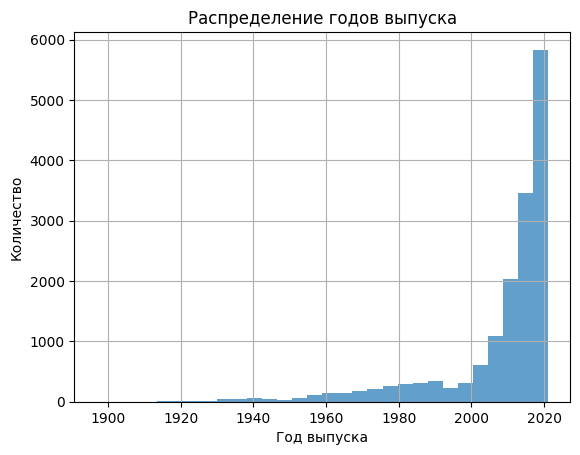

In [ ]:
print(items['release_year'].describe())

items['release_year'].hist(bins=30, alpha=0.7)
plt.title('Распределение годов выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Количество')

Все смотрят один и тот же контент вне зависимости от возрастной группы (нормально ли это?)
Скорее всего особенность платформы, много "свежих фильмов и сериалов" а из старого контента условный Потемкин или что-то похожее.
Зумеры смотрят советские фильмы чуть меньше, чем поколение бейби бума, что странно лично для меня.

**Выведем среднего пользователя, средний продукт и среднее действие пользователя или меры центральной тенденции**

Начнем с действий, вычислим среднее и моду, и заполним пропуски

In [9]:
interactions_total_dur_mean = interactions['total_dur'].mean()
print(interactions_total_dur_mean)

3569.2366236559583


In [10]:
interactions['total_dur'] = interactions['total_dur'].fillna(interactions_total_dur_mean)

In [11]:
interactions_watched_pct_mean = interactions['watched_pct'].mean()
print(interactions_watched_pct_mean)

43.2418462513738


In [12]:
interactions['watched_pct'] = interactions['watched_pct'].fillna(interactions_watched_pct_mean)

In [13]:
interactions.isnull().sum()

,0
user_id,0
item_id,0
last_watch_dt,0
total_dur,0
watched_pct,0


Пропуски кончились, идем к юзерам

In [14]:
users_age_mode = users['age'].mode()[0]
print(users_age_mode)

age_25_34


In [15]:
users['age'] = users['age'].fillna(users_age_mode)

In [16]:
users_income_mode = users['income'].mode()[0]
print(users_income_mode)

income_20_40


In [17]:
users['income'] = users['income'].fillna(users_income_mode)

In [18]:
users_sex_mode = users['sex'].mode()[0]
print(users_sex_mode)

Ж


In [19]:
users['sex'] = users['sex'].fillna(users_sex_mode)

In [20]:
users.isnull().sum()

,0
user_id,0
age,0
income,0
sex,0
kids_flg,0


Средний пользователь сервиса - Женщина примерно 30 лет, с зарплатой 35 тысяч рублей

Заполнять пропуски в фильмах не вижу смысла, так как данные там слишком разные и заполнение средним/модой не добавит смысла и может сделать только хуже.

# Предобработка 2

In [27]:
interactions = interactions[interactions["watched_pct"] >= 60].copy()
interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])

In [28]:
def k_core_filter(interactions, min_user_interactions=3, min_item_interactions=10):

    while True:

        start_shape = interactions.shape[0]

        user_counts = interactions["user_id"].value_counts()
        good_users = user_counts[user_counts >= min_user_interactions].index
        interactions = interactions[interactions["user_id"].isin(good_users)]

        item_counts = interactions["item_id"].value_counts()
        good_items = item_counts[item_counts >= min_item_interactions].index
        interactions = interactions[interactions["item_id"].isin(good_items)]

        end_shape = interactions.shape[0]

        if start_shape == end_shape:
            break

    return interactions

In [29]:
interactions = k_core_filter(
    interactions,
    min_user_interactions=3,
    min_item_interactions=10
)

# Train/Test Split

In [30]:
max_date = interactions["last_watch_dt"].max()
test_start = max_date - pd.Timedelta(days=7)

train = interactions[interactions["last_watch_dt"] < test_start].copy()
test = interactions[interactions["last_watch_dt"] >= test_start].copy()

In [31]:
test = test[
    test["user_id"].isin(train["user_id"]) &
    test["item_id"].isin(train["item_id"])
]

In [32]:
print("Train:", train.shape)
print("Test:", test.shape)

print("Users in train:", train.user_id.nunique())
print("Items in train:", train.item_id.nunique())

Train: (262206, 5)
Test: (14436, 5)
Users in train: 52861
Items in train: 2859


# Random

In [ ]:
all_items = train["item_id"].unique()

test_user_items = test.groupby("user_id")["item_id"].apply(set).to_dict()

users = list(test_user_items.keys())

In [ ]:
def recall_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]

    hits = len(set(recommended) & relevant)

    return hits / len(relevant)

In [ ]:
K = 10
recalls = []

for user in users:

    relevant_items = test_user_items[user]

    # случайные рекомендации
    recommended_items = np.random.choice(all_items, size=K, replace=False)

    recall = recall_at_k(recommended_items, relevant_items, K)

    recalls.append(recall)

random_recall = np.mean(recalls)

print("Random Recall@10:", random_recall)

Random Recall@10: 0.004300681876405953


исключая уже просмотренные фильмы

In [ ]:
train_user_items = train.groupby("user_id")["item_id"].apply(set).to_dict()

for user in users:

    seen_items = train_user_items.get(user, set())
    candidates = list(set(all_items) - seen_items)

    recommended_items = np.random.choice(candidates, size=K, replace=False)

Нормальный результат для random - чуда не случилось

# Popular

In [ ]:
popular_items = (
    train.groupby("item_id")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [ ]:
test_user_items = test.groupby("user_id")["item_id"].apply(set).to_dict()
train_user_items = train.groupby("user_id")["item_id"].apply(set).to_dict()

users = list(test_user_items.keys())

In [ ]:
def recall_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]
    hits = len(set(recommended) & relevant)

    return hits / len(relevant)

In [ ]:
item_id_to_title = dict(zip(items["item_id"], items["title"]))

recalls = []

example_user = users[0]

for user in users:

    relevant_items = test_user_items[user]
    seen_items = train_user_items.get(user, set())

    # убираем просмотренные
    recommended_items = [
        item for item in popular_items if item not in seen_items
    ][:K]

    recall = recall_at_k(recommended_items, relevant_items, K)
    recalls.append(recall)

    if user == example_user:

        print(f"User: {user}\n")
        print("Popular recommendations:\n")

        for i, item in enumerate(recommended_items, 1):
            print(f"{i}. {item_id_to_title.get(item,'Unknown')}")

        print("\nRelevant movies in test:\n")

        for item in relevant_items:
            print(item_id_to_title.get(item,"Unknown"))

popular_recall = np.mean(recalls)

print("\nPopular Recall@10:", popular_recall)

User: 241

Popular recommendations:

1. Гнев человеческий
2. Девятаев
3. Прабабушка легкого поведения
4. Маша
5. Белый снег
6. Аферистка
7. 100% волк
8. День города
9. 2067: Петля времени
10. Стендап под прикрытием

Relevant movies in test:

Экстрасенс 2: Лабиринты разума

Popular Recall@10: 0.07048573125844848


In [ ]:
print(list(item_id_to_title.items())[:5])

[(10711, 'Поговори с ней'), (2508, 'Голые перцы'), (10716, 'Тактическая сила'), (7868, '45 лет'), (16268, 'Все решает мгновение')]


# Item-KNN

In [ ]:
from scipy.sparse import csr_matrix

user_ids = train["user_id"].unique()
item_ids = train["item_id"].unique()

user2idx = {u:i for i,u in enumerate(user_ids)}
item2idx = {i:j for j,i in enumerate(item_ids)}

idx2item = {j:i for i,j in item2idx.items()}

In [ ]:
rows = train["user_id"].map(user2idx)
cols = train["item_id"].map(item2idx)

data = np.ones(len(train))

user_item_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(len(user_ids), len(item_ids))
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_item_sim = cosine_similarity(user_item_matrix.T)

In [ ]:
def recommend_item_knn(user_id, k=10):

    if user_id not in user2idx:
        return []

    user_idx = user2idx[user_id]

    user_items = user_item_matrix[user_idx].indices

    scores = np.zeros(item_item_sim.shape[0])

    for item in user_items:
        scores += item_item_sim[item]

    scores[user_items] = -1

    top_items = np.argsort(scores)[-k:][::-1]

    recs = [idx2item[i] for i in top_items]

    return recs

In [ ]:
example_user = users[0]

recs = recommend_item_knn(example_user, 10)

print("ItemKNN recommendations:\n")

for i,item in enumerate(recs,1):
    print(i, item_id_to_title.get(item,"Unknown"))

ItemKNN recommendations:

1 Артур и война двух миров
2 Суперсемейка 2
3 История игрушек 4
4 История игрушек 2
5 Тачки 2
6 Зверополис
7 Головоломка
8 Университет монстров
9 В поисках Дори
10 Монстры на каникулах 3: Море зовёт


посмотрим данные пользователя, для которого мы реккомендуем фильмы
user_id	 age	        income	        sex	   kids_flg
973171	 age_25_34	  income_60_90	  М	     1


In [ ]:
recalls = []

for user in users:

    recs = recommend_item_knn(user, 10)
    relevant = test_user_items[user]

    recall = recall_at_k(recs, relevant, 10)

    recalls.append(recall)

itemknn_recall = np.mean(recalls)

print("ItemKNN Recall@10:", itemknn_recall)

ItemKNN Recall@10: 0.07273902522907609


# User-KNN

In [ ]:
def recommend_user_knn(user_id, k=10, neighbors=50):

    if user_id not in user2idx:
        return []

    user_idx = user2idx[user_id]

    # считаем similarity только для одного пользователя
    sims = cosine_similarity(
        user_item_matrix[user_idx],
        user_item_matrix
    ).flatten()

    sim_users = np.argsort(sims)[-neighbors-1:-1]

    scores = user_item_matrix[sim_users].sum(axis=0).A1

    seen = user_item_matrix[user_idx].indices
    scores[seen] = -1

    top_items = np.argsort(scores)[-k:][::-1]

    recs = [idx2item[i] for i in top_items]

    return recs

In [ ]:
recalls = []

for user in users:

    recs = recommend_user_knn(user, 10)
    relevant = test_user_items[user]

    recall = recall_at_k(recs, relevant, 10)

    recalls.append(recall)

userknn_recall = np.mean(recalls)

print("UserKNN Recall@10:", userknn_recall)

UserKNN Recall@10: 0.06281492876396702


# ALS

In [27]:
from scipy.sparse import csr_matrix

In [30]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933263 sha256=c6879433643151281379303fcc3e083121e857dea442512db07d269104e06660
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [32]:
import implicit

In [34]:
u_cat = train['user_id'].astype("category")
i_cat = train['item_id'].astype("category")

train['u_idx'] = u_cat.cat.codes
train['i_idx'] = i_cat.cat.codes


user_map = dict(enumerate(u_cat.cat.categories))
item_map = dict(enumerate(i_cat.cat.categories))
user_id_to_idx = {id: idx for idx, id in user_map.items()}


sparse_user_item = csr_matrix((
    train['watched_pct'].astype(np.float32),
    (train['u_idx'], train['i_idx'])
))


model_als = implicit.als.AlternatingLeastSquares(
    factors=128,
    regularization=0.1,
    iterations=20,
    random_state=42
)


model_als.fit(sparse_user_item.T)


als_precisions = []
top_pop = train['item_id'].value_counts().head(10).index.tolist()

for user_id in test_users:
    u_idx = user_id_to_idx.get(user_id)

    if u_idx is not None:
        try:

            ids, scores = model_als.recommend(
                u_idx,
                sparse_user_item[u_idx],
                N=10,
                filter_already_liked_items=True
            )
            recs = [item_map[i] for i in ids]
        except:
            recs = top_pop
    else:
        recs = top_pop

    actual = set(test_true.get(user_id, []))
    hits = len(set(recs) & actual)
    als_precisions.append(hits / 10)

print(f"Исправленный ALS Precision@10: {np.mean(als_precisions):.6f}")

/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.006373405456542969 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

Исправленный ALS Precision@10: 0.009828


# LightFM

In [37]:
!pip install rectools[lightfm]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.1/233.1 kB 8.5 MB/s eta 0:00:00
  Created wheel for rectools-lightfm: filename=rectools_lightfm-1.17.3-cp312-cp312-linux_x86_64.whl size=1074123 sha256=7b5635c70e34c34ee89ea03831acb7cd412d57ad7917e380d1b43d6bea3e7956
  Stored in directory: /root/.cache/pip/wheels/4f/c5/0d/0926e4783dab1901a3750d21a6f18e9589204ef55d747dad94
Successfully built rectools-lightfm
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
 

In [33]:
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import recall_at_k

In [34]:
from rectools import Columns
from rectools.dataset import Dataset

interactions_df = train.rename(columns={
    'user_id': Columns.User,
    'item_id': Columns.Item,
    'last_watch_dt': Columns.Datetime,
    'watched_pct': Columns.Weight
})


user_features_df = users.melt(
    id_vars=Columns.User,
    value_vars=['sex', 'age', 'income'],
    var_name='feature',
    value_name='value'
)


items_features_df = items[['item_id', 'genres']].copy()
items_features_df[Columns.Item] = items_features_df['item_id']
items_features_df['value'] = items_features_df['genres'].str.split(', ')
items_features_df = items_features_df.explode('value')
items_features_df['feature'] = 'genre'
items_features_df = items_features_df[[Columns.Item, 'feature', 'value']]

dataset = Dataset.construct(
    interactions_df,
    user_features_df=user_features_df,
    cat_user_features=['sex', 'age', 'income'],
    item_features_df=items_features_df,
    cat_item_features=['genre']
)

from rectools.models import LightFMWrapperModel
from lightfm import LightFM

lfm_model = LightFM(
    no_components=64,
    loss='warp',
    learning_rate=0.03,
    random_state=42
)

model = LightFMWrapperModel(lfm_model, epochs=35)
model.fit(dataset)

from rectools.metrics import Precision, calc_metrics


recs = model.recommend(
    users=test['user_id'].unique(),
    dataset=dataset,
    k=10,
    filter_viewed=True
)

metrics = calc_metrics(
    metrics={'precision@10': Precision(k=10)},
    reco=recs,
    interactions=test,
    prev_interactions=train,
    catalog=items['item_id'].unique()
)

print(f"LightFM Hybrid Precision@10: {metrics['precision@10']:.6f}")

LightFM Hybrid Precision@10: 0.008987
